# Semana 8: Backward y gradient checking

**Pregunta de trabajo.** Verificar formas, derivadas y entrenamiento de una MLP pequeña antes de escalar el experimento.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def one_hot(y, num_classes):
    y = np.asarray(y, dtype=int)
    out = np.zeros((len(y), num_classes), dtype=float)
    out[np.arange(len(y)), y] = 1.0
    return out


def relu(Z):
    return np.maximum(0.0, Z)


def relu_derivative(Z):
    return (Z > 0).astype(float)


def softmax(Z):
    Z = np.asarray(Z, dtype=float)
    shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def cross_entropy_loss(P, Y, eps=1e-12):
    P = np.clip(P, eps, 1.0)
    return float(-np.sum(Y * np.log(P)) / len(Y))


def init_parameters(n_features, n_hidden, n_classes, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0.0, np.sqrt(2.0 / n_features), size=(n_features, n_hidden))
    b1 = np.zeros(n_hidden)
    W2 = rng.normal(0.0, np.sqrt(2.0 / n_hidden), size=(n_hidden, n_classes))
    b2 = np.zeros(n_classes)
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


def forward_pass(X, params):
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    P = softmax(Z2)
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "P": P}
    return P, cache


def backward_pass(X, Y, cache, params, l2=0.0):
    n = len(X)
    P = cache["P"]
    A1 = cache["A1"]
    Z1 = cache["Z1"]
    W2 = params["W2"]

    dZ2 = (P - Y) / n
    dW2 = A1.T @ dZ2 + l2 * params["W2"]
    db2 = np.sum(dZ2, axis=0)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1 + l2 * params["W1"]
    db1 = np.sum(dZ1, axis=0)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}


def update_parameters(params, grads, lr):
    return {key: value - lr * grads[key] for key, value in params.items()}


def predict(X, params):
    P, _ = forward_pass(X, params)
    return np.argmax(P, axis=1).astype(int)


def train_mlp(X_train, y_train, X_val, y_val, n_hidden=32, lr=0.1, epochs=150, l2=0.0, seed=42):
    n_classes = int(np.max(y_train)) + 1
    Y_train = one_hot(y_train, n_classes)
    params = init_parameters(X_train.shape[1], n_hidden, n_classes, seed=seed)
    history = []
    for epoch in range(epochs):
        P, cache = forward_pass(X_train, params)
        loss = cross_entropy_loss(P, Y_train)
        if l2:
            loss += 0.5 * l2 * (np.sum(params["W1"] ** 2) + np.sum(params["W2"] ** 2))
        grads = backward_pass(X_train, Y_train, cache, params, l2=l2)
        params = update_parameters(params, grads, lr=lr)
        if epoch % 10 == 0 or epoch == epochs - 1:
            train_acc = accuracy_score(y_train, predict(X_train, params))
            val_acc = accuracy_score(y_val, predict(X_val, params))
            history.append({"epoch": epoch, "loss": loss, "train_acc": train_acc, "val_acc": val_acc})
    return params, pd.DataFrame(history)

## Prueba pequeña

In [3]:
X_small = np.array([[0.2, -0.4], [1.0, 0.5], [-0.3, 0.7]])
y_small = np.array([0, 1, 1])
Y_small = one_hot(y_small, 2)
params = init_parameters(2, 3, 2, seed=1)
P, cache = forward_pass(X_small, params)
grads = backward_pass(X_small, Y_small, cache, params)
{k: v.shape for k, v in grads.items()}

{'W1': (2, 3), 'b1': (3,), 'W2': (3, 2), 'b2': (2,)}

## Entrenamiento corto

In [4]:
digits = load_digits()
X = digits.data / 16.0
y = digits.target
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
params, history = train_mlp(X_train[:600], y_train[:600], X_val[:200], y_val[:200], epochs=120, lr=0.2, seed=4)
history.tail()

,epoch,loss,train_acc,val_acc
8,80,0.422272,0.938333,0.870
9,90,0.372858,0.946667,0.890
10,100,0.333777,0.950000,0.905
11,110,0.302072,0.951667,0.915
12,119,0.278268,0.951667,0.925


## Gradient checking y entrenamiento

La prueba numérica usa una red pequeña y después se observa la curva sobre dígitos.

In [5]:
small_params = init_parameters(2, 3, 2, seed=1)
P_small, cache_small = forward_pass(X_small, small_params)
small_grads = backward_pass(X_small, Y_small, cache_small, small_params)

def loss_for_params(X, Y, parameters):
    P, _ = forward_pass(X, parameters)
    return cross_entropy_loss(P, Y)

eps = 1e-5
numeric = []
analytic = []
for index in [(0, 0), (1, 1), (0, 1)]:
    plus = {k: v.copy() for k, v in small_params.items()}
    minus = {k: v.copy() for k, v in small_params.items()}
    plus["W1"][index] += eps
    minus["W1"][index] -= eps
    numeric.append((loss_for_params(X_small, Y_small, plus) - loss_for_params(X_small, Y_small, minus)) / (2 * eps))
    analytic.append(small_grads["W1"][index])
gradient_error = np.linalg.norm(np.array(numeric) - np.array(analytic)) / (np.linalg.norm(numeric) + np.linalg.norm(analytic) + 1e-12)
{"numeric": numeric, "analytic": analytic, "relative_error": gradient_error}

{'numeric': [0.038437416610692665, 0.01088974198037995, 0.006037746203002569],
 'analytic': [0.03843741661036312, 0.010889741967830024, 0.006037746206758355],
 'relative_error': 1.6216270058406605e-10}

In [6]:
P_check, cache_check = forward_pass(X_small, small_params)
dZ2 = (P_check - Y_small) / len(X_small)
{"row_sums_dZ2": dZ2.sum(axis=1), "gradient_shapes": {k: v.shape for k, v in small_grads.items()}}

{'row_sums_dZ2': array([0.00000000e+00, 0.00000000e+00, 2.77555756e-17]),
 'gradient_shapes': {'W1': (2, 3), 'b1': (3,), 'W2': (3, 2), 'b2': (2,)}}

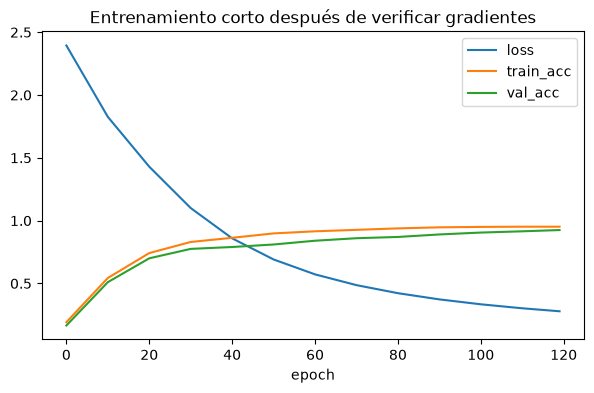

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 4.0))
history.plot(x="epoch", y=["loss", "train_acc", "val_acc"], ax=ax)
ax.set_title("Entrenamiento corto después de verificar gradientes")
plt.show()

In [8]:
final_metrics = {
    "train_accuracy": accuracy_score(y_train[:600], predict(X_train[:600], params)),
    "dev_accuracy": accuracy_score(y_val[:200], predict(X_val[:200], params)),
    "gradient_relative_error": float(gradient_error),
}
assert gradient_error < 1e-6
final_metrics

{'train_accuracy': 0.9516666666666667,
 'dev_accuracy': 0.925,
 'gradient_relative_error': 1.6216270058406605e-10}